In [1]:
from HARey_constellation_cards.harey_main import HAReyMain

harey = HAReyMain()

Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at cardbacks/tarot_round.png


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, PathPatch
from matplotlib.path import Path
import numpy as np

# IMPORTANTE
### NORTHERN EMISPHERE
Hour disk: anticlockwise, 12 to SOUTH
Day disk: clockwise, MARCH 20 to RA 0
### SOUTHERN EMISPHERE
Hour disk: clockwise, 12 to NORTH
Day disk: anticlockwise, MARCH 20 to RA 0


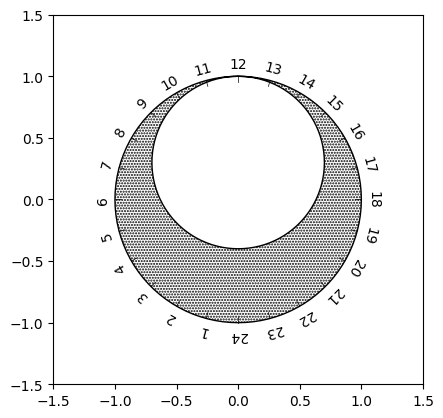

In [3]:
a = np.linspace(0, 2*np.pi, 101)
vertices = []
codes = []

# f flips the plot left and right, depending on the hemisphere
HEMISPHERE = 'S'
f = 1 if HEMISPHERE == 'N' else -1

# Outer circle points
circle = np.array((np.sin(a), np.cos(a))).transpose()
vertices.extend(circle)
codes.extend([Path.MOVETO] + [Path.LINETO]*(circle.shape[0]-2) + [Path.CLOSEPOLY])

# The internal circle is made anticlockwise to create the empty shape
cutout = np.array((0.7*np.sin(-a), 0.3+ 0.7*np.cos(-a))).transpose()
vertices.extend(cutout)
codes.extend([Path.MOVETO] + [Path.LINETO]*(cutout.shape[0]-2) + [Path.CLOSEPOLY])

# Join the two paths into a patch
mask = Path(vertices, codes)
mask = PathPatch(mask, hatch='......', fill=None)

fig, ax = plt.subplots(nrows=1, ncols=1)
# Add the hours marker
for i in range(1,25):
    a = f*i/12*np.pi
    ax.plot((1*np.sin(a),0.95*np.sin(a)), (1*np.cos(a),0.95*np.cos(a)), c='k', lw=0.5)
    ax.text(1.1*np.sin(a), -1.1*np.cos(a), f'{i}', rotation = 180 + f*i*15, ha='center', va='center', rotation_mode='anchor')
ax.add_patch(mask)
ax.set_xlim(-1.5,1.5)
ax.set_ylim(-1.5,1.5)
ax.set_aspect('equal')
plt.show()

In [4]:
from datetime import datetime
from calendar import monthrange

[]

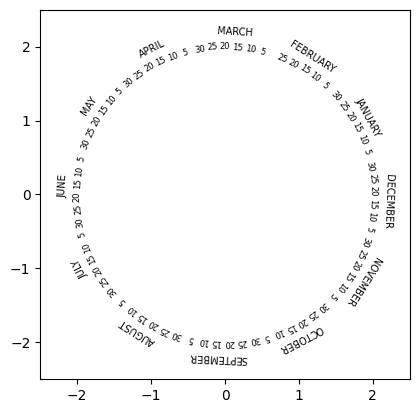

In [5]:
fig, ax = plt.subplots()
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)

# Angle of the spring Equinox, which correspond to the 0 RA value
equinox_offest = datetime(2001,3,20).timetuple().tm_yday/365

for m in range(1,13):
    days_in_month = monthrange(2001,m)[1]

    # Plot the day label
    for day in range(5,days_in_month+1,5):
        # Get the angle as a fraction of the whole year
        angle = f*(datetime(2001, m, day).timetuple().tm_yday/365 - equinox_offest)
        a = 2*np.pi*angle
        ax.text(2*np.sin(a), 2*np.cos(a), f'{day}', ha='center', va='center', rotation=-angle*360, fontsize=6)

    # Plot the month label
    angle = f*((datetime(2001, m, 1).timetuple().tm_yday + days_in_month/2)/365 - equinox_offest)
    a = 2*np.pi*angle
    month_name = f'{datetime(2001,m,1).strftime('%B').upper()}'
    ax.text(2.2*np.sin(a), 2.2*np.cos(a), month_name, ha='center', va='center', rotation=-angle*360, fontsize=7)
    
ax.set_aspect('equal')
plt.plot()
